<a href="https://colab.research.google.com/github/TheJcabal/UNI_WORKS/blob/main/DFS_DFS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Un ejmplo sencillo de Busqueda por anchura (BFS) y busqueda profunda (DFS)

Busqueda BFS:
A -> B -> C -> D -> E -> F

Busqueda DFS:
A -> B -> D -> E -> F -> C


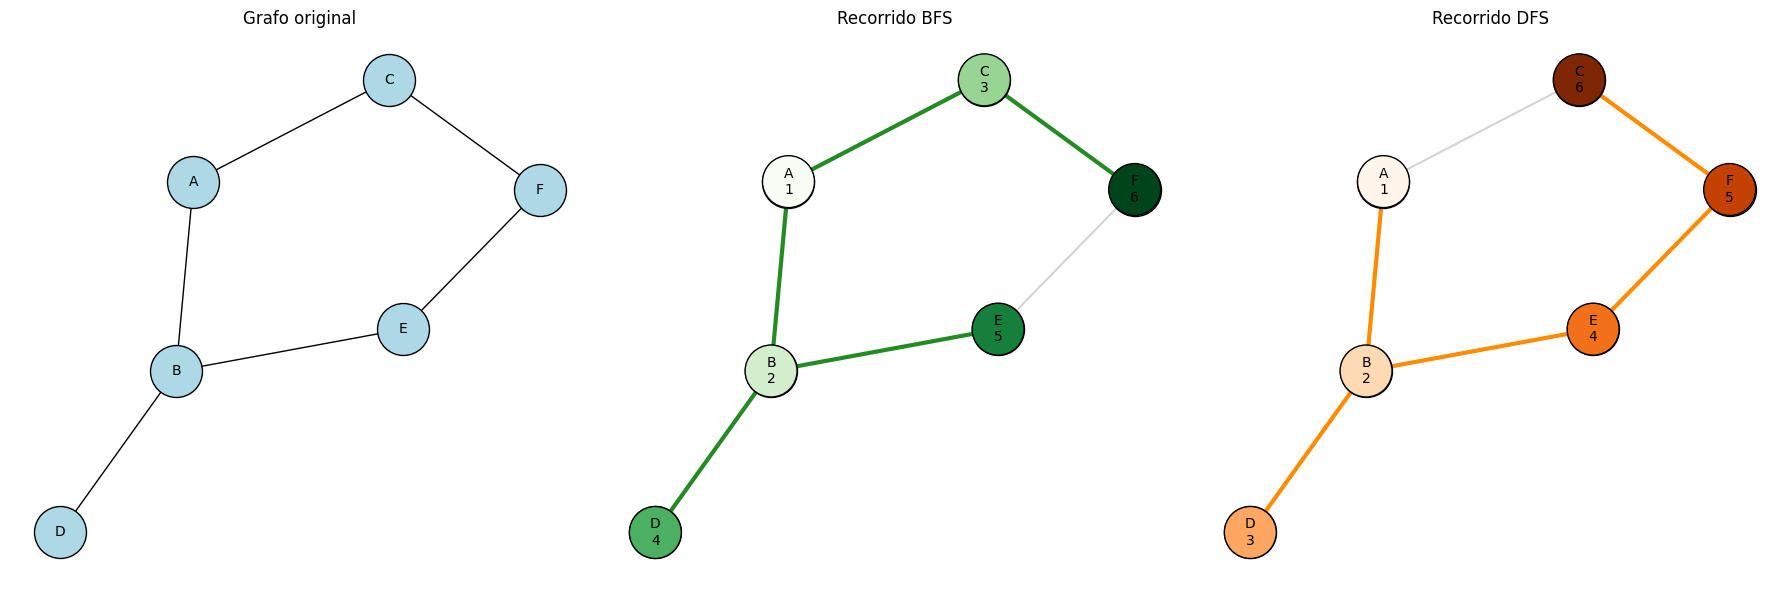

In [ ]:
# usando los algoritmos BFS y DFS en un ejemplo sencillo
# graficando el orden y las aristas recorridas en cada metodo
from collections import deque

import matplotlib.pyplot as plt
import networkx as nx


# primero, defino el grafo como un diccionario de listas
grafo = {
    'A': ['B', 'C'],
    'B': ['A', 'D', 'E'],
    'C': ['A', 'F'],
    'D': ['B'],
    'E': ['B', 'F'],
    'F': ['C', 'E']
}


def bfs(grafo, inicio):
    visitados = set()
    descubiertos = {inicio}
    cola = deque([inicio])
    orden = []
    aristas_recorrido = []

    while cola:
        nodo = cola.popleft()
        if nodo in visitados:
            continue

        orden.append(nodo)
        visitados.add(nodo)

        for vecino in grafo[nodo]:
            if vecino not in descubiertos:
                descubiertos.add(vecino)
                cola.append(vecino)
                aristas_recorrido.append((nodo, vecino))

    return orden, aristas_recorrido


def dfs(grafo, inicio, visitados=None, orden=None, aristas_recorrido=None):
    if visitados is None:
        visitados = set()
    if orden is None:
        orden = []
    if aristas_recorrido is None:
        aristas_recorrido = []

    visitados.add(inicio)
    orden.append(inicio)

    for vecino in grafo[inicio]:
        if vecino not in visitados:
            aristas_recorrido.append((inicio, vecino))
            dfs(grafo, vecino, visitados, orden, aristas_recorrido)

    return orden, aristas_recorrido


def etiquetas_con_orden(orden):
    return {nodo: f"{nodo}\n{paso}" for paso, nodo in enumerate(orden, start=1)}


def dibujar_recorrido(ax, grafo_base, pos, orden, aristas_recorrido, titulo, mapa_colores, color_aristas):
    ax.set_title(titulo)
    nx.draw_networkx_edges(grafo_base, pos, ax=ax, edge_color='lightgray', width=1.5)
    nx.draw_networkx_nodes(
        grafo_base,
        pos,
        ax=ax,
        node_color='whitesmoke',
        edgecolors='black',
        node_size=1400,
    )
    nx.draw_networkx_edges(
        grafo_base,
        pos,
        ax=ax,
        edgelist=aristas_recorrido,
        edge_color=color_aristas,
        width=3,
    )
    nx.draw_networkx_nodes(
        grafo_base,
        pos,
        ax=ax,
        nodelist=orden,
        node_color=list(range(len(orden))),
        cmap=mapa_colores,
        edgecolors='black',
        node_size=1400,
    )
    nx.draw_networkx_labels(
        grafo_base,
        pos,
        ax=ax,
        labels=etiquetas_con_orden(orden),
        font_size=10,
    )
    ax.axis('off')


orden_bfs, aristas_bfs = bfs(grafo, 'A')
orden_dfs, aristas_dfs = dfs(grafo, 'A')

print('Busqueda BFS:')
print(' -> '.join(orden_bfs))
print('\nBusqueda DFS:')
print(' -> '.join(orden_dfs))

G = nx.Graph(grafo)
pos = nx.spring_layout(G, seed=7)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

nx.draw(
    G,
    pos,
    ax=axes[0],
    with_labels=True,
    node_color='lightblue',
    node_size=1400,
    edgecolors='black',
    font_size=10,
)
axes[0].set_title('Grafo original')
axes[0].axis('off')

dibujar_recorrido(axes[1], G, pos, orden_bfs, aristas_bfs, 'Recorrido BFS', 'Greens', 'forestgreen')
dibujar_recorrido(axes[2], G, pos, orden_dfs, aristas_dfs, 'Recorrido DFS', 'Oranges', 'darkorange')

plt.tight_layout()
plt.show()

